# **TUGAS 3**

1. Kolom sepal_width
2. Baris ke-39 dihilangkan
3. Kemudian diprediksi menggunakan KNN dari data lain

Rumus yang dipakai KNN:

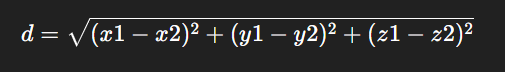

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import NearestNeighbors

## Data Awal
Data awal yang terdapat data kosong berada di baris 39 sepal_width

In [9]:
# Load dataset iris
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=['sepal_length','sepal_width','petal_length','petal_width']
)

# Salin data
df_missing = df.copy()

# Hilangkan nilai sepal_width pada baris 39
df_missing.loc[39,'sepal_width'] = np.nan

print("DATA SEBELUM PERHITUNGAN")
print(df_missing.loc[35:45])

DATA SEBELUM PERHITUNGAN
    sepal_length  sepal_width  petal_length  petal_width
35           5.0          3.2           1.2          0.2
36           5.5          3.5           1.3          0.2
37           4.9          3.6           1.4          0.1
38           4.4          3.0           1.3          0.2
39           5.1          NaN           1.5          0.2
40           5.0          3.5           1.3          0.3
41           4.5          2.3           1.3          0.3
42           4.4          3.2           1.3          0.2
43           5.0          3.5           1.6          0.6
44           5.1          3.8           1.9          0.4
45           4.8          3.0           1.4          0.3


## Perhitungan KNN
untuk Mencari data yang Paling dekat dengan data kosong

In [10]:
# Ambil data yang lengkap
train_data = df_missing.dropna()

# Model KNN
knn = NearestNeighbors(n_neighbors=3)

# Fit model
knn.fit(train_data[['sepal_length','petal_length','petal_width']])

# Data yang kosong
data_missing = df_missing.loc[[39],['sepal_length','petal_length','petal_width']]

# Cari tetangga terdekat
distances, indices = knn.kneighbors(data_missing)

# Ambil data tetangga
neighbors = train_data.iloc[indices[0]]

print("\nDATA YANG HILANG")
print(df_missing.loc[39])

print("\n3 DATA TERDEKAT (NEIGHBORS)")
print(neighbors)

print("\nJARAK KE MASING-MASING DATA")
for i, idx in enumerate(indices[0]):
    print(f"Index data: {train_data.index[idx]}, Jarak: {distances[0][i]}")


DATA YANG HILANG
sepal_length    5.1
sepal_width     NaN
petal_length    1.5
petal_width     0.2
Name: 39, dtype: float64

3 DATA TERDEKAT (NEIGHBORS)
    sepal_length  sepal_width  petal_length  petal_width
7            5.0          3.4           1.5          0.2
19           5.1          3.8           1.5          0.3
0            5.1          3.5           1.4          0.2

JARAK KE MASING-MASING DATA
Index data: 7, Jarak: 0.09999999999999964
Index data: 19, Jarak: 0.09999999999999998
Index data: 0, Jarak: 0.10000000000000009


## Tabel Hasil Perhitungan KNN

In [11]:
# Hitung nilai pengganti dari rata-rata tetangga
estimated_value = neighbors['sepal_width'].mean()

# Isi nilai yang hilang
df_missing.loc[39,'sepal_width'] = estimated_value

print("\nDATA SETELAH PERHITUNGAN KNN")
print(df_missing.loc[35:45])

print("\nNilai hasil estimasi sepal_width =", estimated_value)


DATA SETELAH PERHITUNGAN KNN
    sepal_length  sepal_width  petal_length  petal_width
35           5.0     3.200000           1.2          0.2
36           5.5     3.500000           1.3          0.2
37           4.9     3.600000           1.4          0.1
38           4.4     3.000000           1.3          0.2
39           5.1     3.566667           1.5          0.2
40           5.0     3.500000           1.3          0.3
41           4.5     2.300000           1.3          0.3
42           4.4     3.200000           1.3          0.2
43           5.0     3.500000           1.6          0.6
44           5.1     3.800000           1.9          0.4
45           4.8     3.000000           1.4          0.3

Nilai hasil estimasi sepal_width = 3.5666666666666664
